🌟 ENHANCED CLASSIFICATION SYSTEM WITH DATA AUGMENTATION
📂 Dataset: F:\_____My_Thesies____\_ImpFiles\4. LULC\1.Feature_Engineered\2.RawFeature_AllClass\final_dataset_all.csv
📁 Results will be saved in: Enhanced_Classification_Results_AllClasses_NOFE_Aug
🚀 STARTING ENHANCED CLASSIFICATION ANALYSIS
🔄 Loading and preparing data...
✅ Data loaded successfully! Total Shape: (6318, 2782)
📊 Labeled samples: 454
🔍 Unlabeled samples: 5864
🎯 Target classes: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
🔧 Found 2778 feature columns

📊 CLASS DISTRIBUTION ANALYSIS:
Alfalfa-polygon: 33 samples (7.3%)
Bare-polygon: 39 samples (8.6%)
Clover-polygon: 14 samples (3.1%)
Corn-polygon: 6 samples (1.3%)
Degreed_Wetland_Poly-polygon: 6 samples (1.3%)
Mixed_TP-polygon: 3 samples (0.7%)
Phragmites-polygon: 17

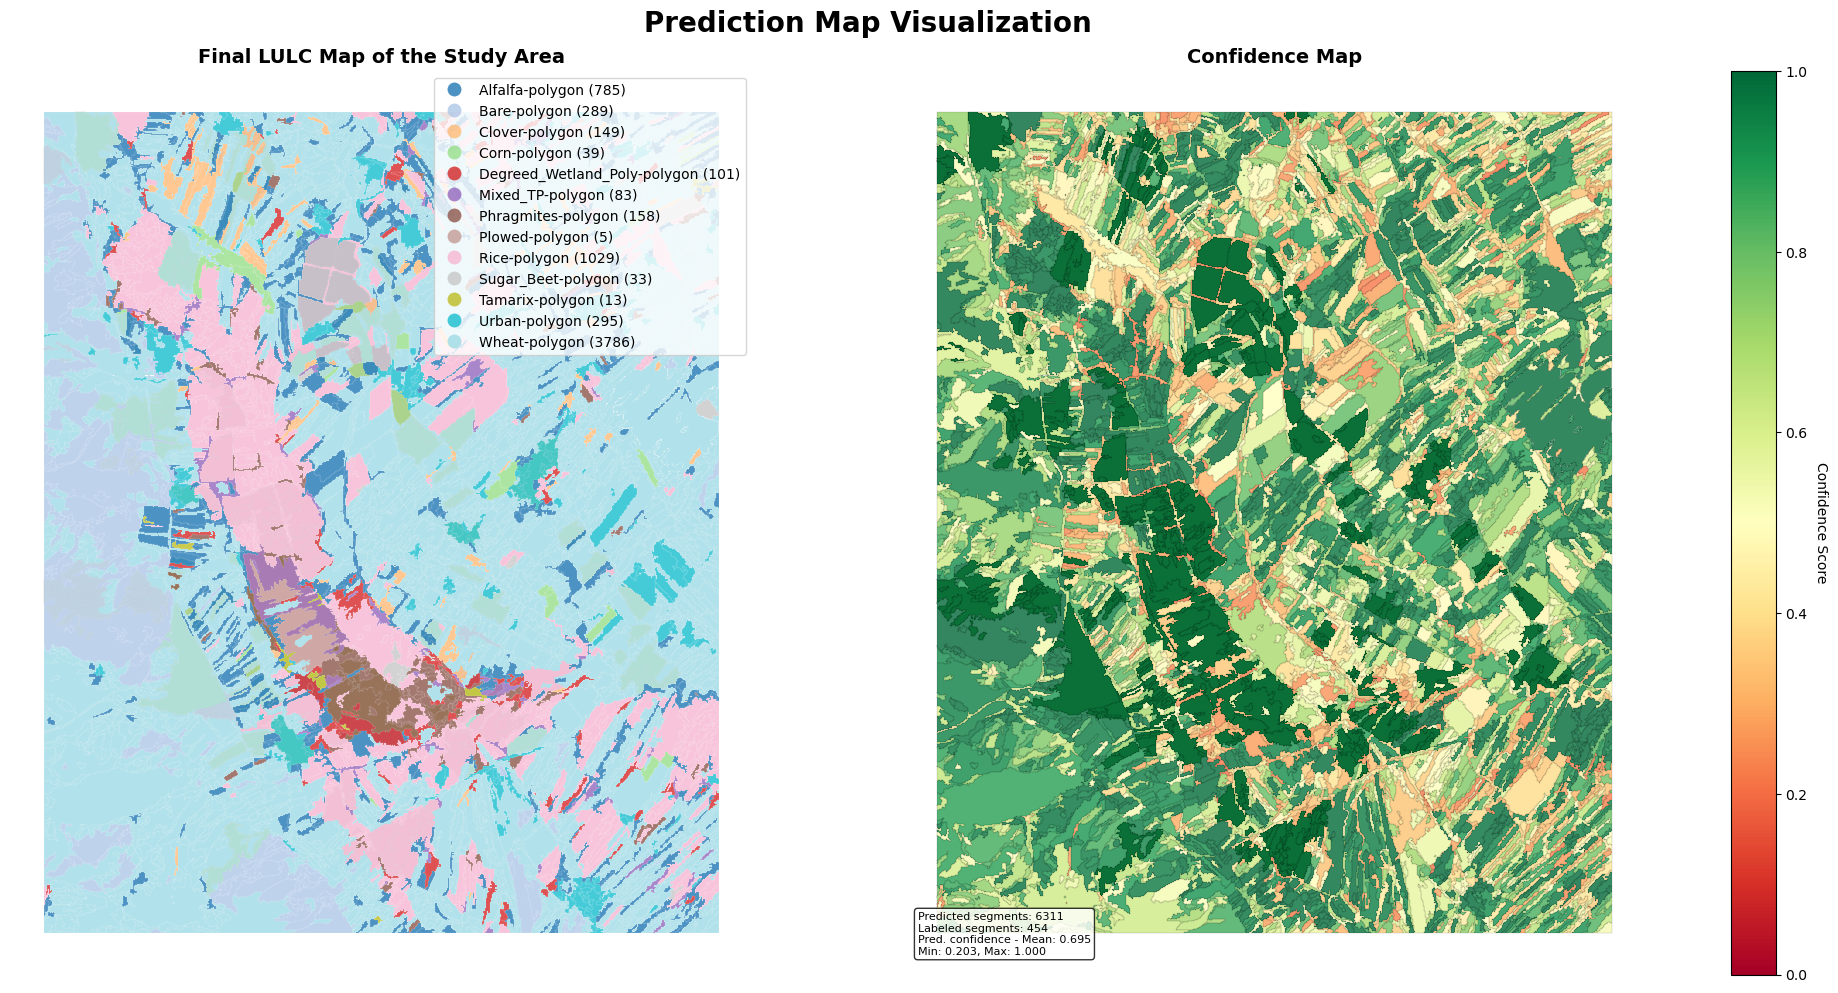


💾 Saving model and results...
✅ Model saved: Enhanced_Classification_Results_AllClasses_NOFE_Aug/best_model_pipeline.pkl
✅ Label encoder saved: Enhanced_Classification_Results_AllClasses_NOFE_Aug/label_encoder.pkl
✅ Results summary saved: Enhanced_Classification_Results_AllClasses_NOFE_Aug/results_summary.json
✅ Feature importance saved: Enhanced_Classification_Results_AllClasses_NOFE_Aug/feature_importance.csv
✅ All files saved successfully!

📄 Generating final report...
ENHANCED CLASSIFICATION SYSTEM - FINAL REPORT
Generated: 2025-10-11 14:39:41
Dataset: final_dataset_all.csv

DATASET OVERVIEW:
------------------------------
Total samples: 6,318
Labeled samples: 454
Unlabeled samples: 5,864
Number of features: 2778
Number of classes: 13
Classes: Alfalfa-polygon, Bare-polygon, Clover-polygon, Corn-polygon, Degreed_Wetland_Poly-polygon, Mixed_TP-polygon, Phragmites-polygon, Plowed-polygon, Rice-polygon, Sugar_Beet-polygon, Tamarix-polygon, Urban-polygon, Wheat-polygon

ORIGINAL CLASS 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, 
    cross_validate, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, precision_recall_fscore_support
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import os
from datetime import datetime
import json
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt

class EnhancedClassificationSystem:
    def __init__(self, csv_path, results_dir="Enhanced_Classification_Results"):
        """
        Initialize Enhanced Classification System with Data Augmentation
        
        Args:
            csv_path (str): Path to the CSV file
            results_dir (str): Directory to save results
        """
        self.csv_path = csv_path
        self.results_dir = results_dir
        os.makedirs(self.results_dir, exist_ok=True)
        
        # Data attributes
        self.df = None
        self.labeled_data = None
        self.unlabeled_data = None
        self.X_labeled = None
        self.y_labeled = None
        self.X_unlabeled = None
        self.feature_names = None
        self.class_names = None
        self.label_encoder = None
        self.scaler = None
        
        # Augmented datasets
        self.augmented_datasets = {}
        self.augmentation_results = {}
        
        # Best model attributes
        self.best_model = None
        self.best_pipeline = None
        self.best_strategy = None
        self.best_score = 0
        
        # Results storage
        self.final_results = {}
        
        # For map
        self.input_csv = os.path.join(self.results_dir, 'final_dataset_enhanced_all.csv')
        self.base_csv = self.csv_path
        self.output_dir = self.results_dir
        self.predictions_df = None

    def load_and_prepare_data(self):
        """Load CSV and prepare data for analysis"""
        print("🔄 Loading and preparing data...")
        print("="*60)
        
        # Load CSV
        self.df = pd.read_csv(self.csv_path)
        print(f"✅ Data loaded successfully! Total Shape: {self.df.shape}")
        
        # Check for layer column
        if 'layer' not in self.df.columns:
            raise ValueError("❌ 'layer' column not found in the dataset!")
        
        # Separate labeled and unlabeled data
        labeled_mask = (self.df['layer'].notna()) & (self.df['layer'] != '') & (self.df['layer'] != 'Unknown')
        
        self.labeled_data = self.df[labeled_mask].copy()
        self.unlabeled_data = self.df[~labeled_mask].copy()
        
        print(f"📊 Labeled samples: {len(self.labeled_data)}")
        print(f"🔍 Unlabeled samples: {len(self.unlabeled_data)}")
        print(f"🎯 Target classes: {sorted(self.labeled_data['layer'].unique())}")
        
        if len(self.labeled_data) == 0:
            raise ValueError("❌ No labeled data found for training!")
        
        # Identify feature columns
        exclude_cols = ['geometry', 'label', 'layer']
        feature_cols = [col for col in self.df.columns if col not in exclude_cols]
        feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(self.df[col])]

        if len(feature_cols) == 0:
            raise ValueError("❌ No feature columns found!")
        
        print(f"🔧 Found {len(feature_cols)} feature columns")
        
        # Prepare features and target for labeled data
        self.X_labeled = self.labeled_data[feature_cols].fillna(0)
        self.y_labeled = self.labeled_data['layer']
        
        # Prepare features for unlabeled data
        if len(self.unlabeled_data) > 0:
            self.X_unlabeled = self.unlabeled_data[feature_cols].fillna(0)
        
        self.feature_names = feature_cols
        
        # Encode labels
        self.label_encoder = LabelEncoder()
        self.y_labeled_encoded = self.label_encoder.fit_transform(self.y_labeled)
        self.class_names = list(self.label_encoder.classes_)
        
        # Analyze class distribution
        self._analyze_class_distribution()
        
        print(f"✅ Data preparation completed!")
        return self
    
    def _analyze_class_distribution(self):
        """Analyze and display class distribution"""
        print("\n📊 CLASS DISTRIBUTION ANALYSIS:")
        print("="*50)
        
        unique, counts = np.unique(self.y_labeled_encoded, return_counts=True)
        class_dist = dict(zip(unique, counts))
        
        total_samples = len(self.y_labeled_encoded)
        for i, (class_idx, count) in enumerate(class_dist.items()):
            class_name = self.class_names[class_idx]
            percentage = (count / total_samples) * 100
            print(f"{class_name}: {count} samples ({percentage:.1f}%)")
        
        min_class_size = min(counts)
        max_class_size = max(counts)
        imbalance_ratio = max_class_size / min_class_size
        
        print(f"\n📈 Imbalance Analysis:")
        print(f"Min class size: {min_class_size}")
        print(f"Max class size: {max_class_size}")
        print(f"Imbalance ratio: {imbalance_ratio:.2f}")
        
        if imbalance_ratio > 5:
            print("⚠️  Dataset is imbalanced - augmentation HIGHLY recommended!")
        else:
            print("✅ Dataset is relatively balanced")
    
    def create_augmented_datasets(self):
        """Create multiple augmented versions of the dataset"""
        print("\n🔄 Creating augmented datasets...")
        print("="*60)
        
        # 1. Original dataset (baseline)
        self.augmented_datasets['Original'] = (self.X_labeled, self.y_labeled_encoded)
        print(f"✅ Original: {len(self.y_labeled_encoded)} samples")
        
        # Feature selection for augmentation (reduce dimensionality)
        n_features_select = min(100, max(20, len(self.y_labeled_encoded) // 5))
        selector = SelectKBest(f_classif, k=n_features_select)
        X_selected = selector.fit_transform(self.X_labeled, self.y_labeled_encoded)
        
        print(f"🔧 Selected {n_features_select} most important features for augmentation")
        
        # 2. SMOTE (Synthetic Minority Oversampling)
        try:
            k_neighbors = min(3, len(self.y_labeled_encoded)//len(np.unique(self.y_labeled_encoded))-1)
            smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
            X_smote, y_smote = smote.fit_resample(X_selected, self.y_labeled_encoded)
            # Expand back to full feature space
            X_smote_full = self._expand_features(X_smote, selector)
            self.augmented_datasets['SMOTE'] = (X_smote_full, y_smote)
            print(f"✅ SMOTE: {len(y_smote)} samples (+{len(y_smote)-len(self.y_labeled_encoded)})")
        except Exception as e:
            print(f"❌ SMOTE failed: {str(e)}")
        
        # 3. ADASYN (Adaptive Synthetic Sampling)
        try:
            k_neighbors = min(3, len(self.y_labeled_encoded)//len(np.unique(self.y_labeled_encoded))-1)
            adasyn = ADASYN(random_state=42, n_neighbors=k_neighbors)
            X_adasyn, y_adasyn = adasyn.fit_resample(X_selected, self.y_labeled_encoded)
            X_adasyn_full = self._expand_features(X_adasyn, selector)
            self.augmented_datasets['ADASYN'] = (X_adasyn_full, y_adasyn)
            print(f"✅ ADASYN: {len(y_adasyn)} samples (+{len(y_adasyn)-len(self.y_labeled_encoded)})")
        except Exception as e:
            print(f"❌ ADASYN failed: {str(e)}")
        
        # 4. Borderline SMOTE
        try:
            k_neighbors = min(3, len(self.y_labeled_encoded)//len(np.unique(self.y_labeled_encoded))-1)
            borderline_smote = BorderlineSMOTE(random_state=42, k_neighbors=k_neighbors)
            X_borderline, y_borderline = borderline_smote.fit_resample(X_selected, self.y_labeled_encoded)
            X_borderline_full = self._expand_features(X_borderline, selector)
            self.augmented_datasets['Borderline_SMOTE'] = (X_borderline_full, y_borderline)
            print(f"✅ Borderline SMOTE: {len(y_borderline)} samples (+{len(y_borderline)-len(self.y_labeled_encoded)})")
        except Exception as e:
            print(f"❌ Borderline SMOTE failed: {str(e)}")
        
        # 5. SMOTE + Tomek Links
        try:
            smote_tomek = SMOTETomek(random_state=42)
            X_smote_tomek, y_smote_tomek = smote_tomek.fit_resample(X_selected, self.y_labeled_encoded)
            X_smote_tomek_full = self._expand_features(X_smote_tomek, selector)
            self.augmented_datasets['SMOTE_Tomek'] = (X_smote_tomek_full, y_smote_tomek)
            print(f"✅ SMOTE + Tomek: {len(y_smote_tomek)} samples")
        except Exception as e:
            print(f"❌ SMOTE + Tomek failed: {str(e)}")
        
        # 6. Bootstrap Augmentation
        X_bootstrap, y_bootstrap = self._bootstrap_augmentation()
        self.augmented_datasets['Bootstrap'] = (X_bootstrap, y_bootstrap)
        print(f"✅ Bootstrap: {len(y_bootstrap)} samples")
        
        # 7. Gaussian Noise Augmentation
        X_noise, y_noise = self._gaussian_noise_augmentation()
        self.augmented_datasets['Gaussian_Noise'] = (X_noise, y_noise)
        print(f"✅ Gaussian Noise: {len(y_noise)} samples")
        
        return self
    
    def _expand_features(self, X_reduced, selector):
        """Expand reduced features back to full feature space"""
        X_full = np.zeros((X_reduced.shape[0], len(self.feature_names)))
        X_full[:, selector.get_support(indices=True)] = X_reduced
        return pd.DataFrame(X_full, columns=self.feature_names)
    
    def _bootstrap_augmentation(self, multiplier=1.8):
        """Bootstrap sampling with slight noise"""
        n_samples = len(self.y_labeled_encoded)
        target_samples = int(n_samples * multiplier)
        
        indices = np.random.choice(n_samples, size=target_samples, replace=True)
        X_bootstrap = self.X_labeled.iloc[indices].copy()
        y_bootstrap = self.y_labeled_encoded[indices]
        
        # Add slight noise to prevent exact duplicates
        noise_factor = 0.001
        noise = np.random.normal(0, noise_factor * np.std(X_bootstrap.values, axis=0), X_bootstrap.shape)
        X_bootstrap += noise
        
        return X_bootstrap, y_bootstrap
    
    def _gaussian_noise_augmentation(self, noise_factor=0.01, multiplier=1.5):
        """Add Gaussian noise to create synthetic samples"""
        n_samples = len(self.y_labeled_encoded)
        n_synthetic = int(n_samples * (multiplier - 1))
        
        indices = np.random.choice(n_samples, size=n_synthetic, replace=True)
        X_selected = self.X_labeled.iloc[indices].values
        X_original = self.X_labeled.values
        
        # Add Gaussian noise
        noise = np.random.normal(0, noise_factor * np.std(X_original, axis=0), X_selected.shape)
        X_synthetic = X_selected + noise
        y_synthetic = self.y_labeled_encoded[indices]
        
        # Combine original and synthetic
        X_combined = np.vstack([X_original, X_synthetic])
        y_combined = np.hstack([self.y_labeled_encoded, y_synthetic])
        
        X_combined_df = pd.DataFrame(X_combined, columns=self.feature_names)
        
        return X_combined_df, y_combined
    
    def evaluate_augmentation_strategies(self):
        """Evaluate all augmentation strategies using cross-validation"""
        print("\n🚀 Evaluating augmentation strategies...")
        print("="*70)
        
        # Cross-validation strategies
        cv_strategies = {
            'StratifiedKFold_5': StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
            'RepeatedStratifiedKFold': RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
        }
        
        # Models to test
        models = {
            'Random_Forest': RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ),
            'Extra_Trees': ExtraTreesClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        }
        
        best_overall_score = 0
        best_config = None
        
        for aug_name, (X_aug, y_aug) in self.augmented_datasets.items():
            print(f"\n📊 Testing {aug_name} (samples: {len(y_aug)})...")
            
            for cv_name, cv_strategy in cv_strategies.items():
                for model_name, model in models.items():
                    
                    # Create pipeline with feature selection and scaling
                    n_features_select = min(50, max(10, len(y_aug) // 10))
                    
                    pipeline = Pipeline([
                        ('scaler', StandardScaler()),
                        ('feature_selection', SelectKBest(f_classif, k=n_features_select)),
                        ('classifier', model)
                    ])
                    
                    try:
                        # Perform cross-validation
                        cv_results = cross_validate(
                            pipeline, X_aug, y_aug, cv=cv_strategy,
                            scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
                            return_train_score=True,
                            n_jobs=-1
                        )
                        
                        config_name = f"{aug_name}_{model_name}_{cv_name}"
                        
                        results = {
                            'augmentation': aug_name,
                            'model': model_name,
                            'cv_strategy': cv_name,
                            'n_samples': len(y_aug),
                            'n_features_selected': n_features_select,
                            'test_accuracy_mean': cv_results['test_accuracy'].mean(),
                            'test_accuracy_std': cv_results['test_accuracy'].std(),
                            'test_f1_mean': cv_results['test_f1_macro'].mean(),
                            'test_f1_std': cv_results['test_f1_macro'].std(),
                            'test_precision_mean': cv_results['test_precision_macro'].mean(),
                            'test_recall_mean': cv_results['test_recall_macro'].mean(),
                            'train_accuracy_mean': cv_results['train_accuracy'].mean(),
                            'overfitting_gap': cv_results['train_accuracy'].mean() - cv_results['test_accuracy'].mean(),
                            'cv_results': cv_results
                        }
                        
                        self.augmentation_results[config_name] = results
                        
                        # Track best configuration
                        current_score = results['test_accuracy_mean']
                        if current_score > best_overall_score:
                            best_overall_score = current_score
                            best_config = config_name
                            self.best_strategy = aug_name
                            self.best_score = current_score
                        
                        print(f"   {model_name} + {cv_name}: "
                              f"Acc={results['test_accuracy_mean']:.4f}±{results['test_accuracy_std']:.4f}, "
                              f"F1={results['test_f1_mean']:.4f}±{results['test_f1_std']:.4f}")
                        
                    except Exception as e:
                        print(f"   ❌ {model_name} + {cv_name} failed: {str(e)}")
        
        print(f"\n🏆 BEST CONFIGURATION: {best_config}")
        print(f"🎯 Best Accuracy: {best_overall_score:.4f}")
        
        return self._create_comparison_report()
    
    def _create_comparison_report(self):
        """Create detailed comparison report"""
        print("\n📋 DETAILED COMPARISON REPORT:")
        print("="*100)
        
        # Create comparison DataFrame
        comparison_data = []
        for config_name, results in self.augmentation_results.items():
            comparison_data.append({
                'Configuration': config_name,
                'Augmentation': results['augmentation'],
                'Model': results['model'],
                'CV_Strategy': results['cv_strategy'],
                'Samples': results['n_samples'],
                'Features': results['n_features_selected'],
                'Test_Accuracy': results['test_accuracy_mean'],
                'Accuracy_Std': results['test_accuracy_std'],
                'Test_F1': results['test_f1_mean'],
                'F1_Std': results['test_f1_std'],
                'Precision': results['test_precision_mean'],
                'Recall': results['test_recall_mean'],
                'Overfitting': results['overfitting_gap']
            })
        
        if not comparison_data:
            print("❌ No successful configurations found!")
            return None
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('Test_Accuracy', ascending=False)
        
        # Display top 10 configurations
        print("🔝 TOP 10 CONFIGURATIONS:")
        top_10 = comparison_df.head(10)[['Configuration', 'Test_Accuracy', 'Test_F1', 'Overfitting']].round(4)
        print(top_10.to_string(index=False))
        
        # Save detailed results
        comparison_df.to_csv(f'{self.results_dir}/augmentation_comparison.csv', index=False)
        print(f"\n💾 Detailed results saved: {self.results_dir}/augmentation_comparison.csv")
        
        return comparison_df
    
    def train_best_model(self):
        """Train the best model on the best augmented dataset"""
        print(f"\n🚀 Training best model with {self.best_strategy} augmentation...")
        print("="*60)
        
        # Get best augmented data
        X_best, y_best = self.augmented_datasets[self.best_strategy]
        
        # Create best pipeline
        n_features_select = min(50, max(10, len(y_best) // 10))
        
        self.best_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(f_classif, k=n_features_select)),
            ('classifier', RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_split=5,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            ))
        ])
        
        # Split for final evaluation
        X_train, X_test, y_train, y_test = train_test_split(
            X_best, y_best, test_size=0.2, random_state=42, stratify=y_best
        )
        
        # Train the model
        self.best_pipeline.fit(X_train, y_train)
        
        # Make predictions
        y_pred_train = self.best_pipeline.predict(X_train)
        y_pred_test = self.best_pipeline.predict(X_test)
        
        # Calculate metrics
        train_accuracy = accuracy_score(y_train, y_pred_train)
        test_accuracy = accuracy_score(y_test, y_pred_test)
        
        print(f"✅ Model trained successfully!")
        print(f"🎯 Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
        print(f"🎯 Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
        print(f"📊 Overfitting Gap: {(train_accuracy - test_accuracy):.4f}")
        
        # Store final results
        self.final_results = {
            'best_strategy': self.best_strategy,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'overfitting_gap': train_accuracy - test_accuracy,
            'n_train_samples': len(y_train),
            'n_test_samples': len(y_test),
            'n_features_selected': n_features_select,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred_test': y_pred_test,
            'X_train': X_train,
            'y_train': y_train,
            'y_pred_train': y_pred_train
        }
        
        return self
    
    def create_detailed_evaluation(self):
        """Create detailed evaluation metrics and visualizations"""
        print("\n📊 Creating detailed evaluation...")
        print("="*50)
        
        y_test = self.final_results['y_test']
        y_pred_test = self.final_results['y_pred_test']
        
        # Get the actual classes present in the test set
        unique_classes = np.unique(np.concatenate([y_test, y_pred_test]))
        present_class_names = [self.class_names[i] for i in unique_classes]
        
        print(f"📊 Classes in test set: {len(unique_classes)} out of {len(self.class_names)} total classes")
        if len(unique_classes) < len(self.class_names):
            missing_classes = [self.class_names[i] for i in range(len(self.class_names)) if i not in unique_classes]
            print(f"⚠️  Missing classes in test set: {missing_classes}")
        
        # 1. Classification Report - use only present classes
        class_report = classification_report(
            y_test, y_pred_test, 
            target_names=present_class_names,
            labels=unique_classes,
            output_dict=True,
            zero_division=0
        )
        
        print("📋 CLASSIFICATION REPORT:")
        print(classification_report(y_test, y_pred_test, target_names=present_class_names, labels=unique_classes, zero_division=0))
        
        # 2. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred_test)
        
        # 3. Feature Importance
        feature_importance = self._get_feature_importance()
        
        # 4. Create visualizations
        self._create_visualizations(class_report, cm, feature_importance, y_test, y_pred_test, present_class_names, unique_classes)
        
        # 5. Predict unlabeled data
        predictions_df = self._predict_unlabeled_data()
        if predictions_df is not None:
            self.predictions_df = predictions_df

            # Create combined dataset for map
            labeled_pred = self.labeled_data.copy()
            labeled_pred['predicted_layer'] = labeled_pred['layer']
            labeled_pred['prediction_confidence'] = 0.99

            # Add prob columns if present
            prob_cols = [col for col in predictions_df.columns if col.startswith('prob_')]
            if prob_cols:
                for col in prob_cols:
                    labeled_pred[col] = 0.0
                for class_name in self.class_names:
                    col = f'prob_{class_name}'
                    if col in labeled_pred.columns:
                        labeled_pred.loc[labeled_pred['predicted_layer'] == class_name, col] = 1.0

            # Combine
            combined_df = pd.concat([labeled_pred, predictions_df], ignore_index=True)
            combined_df.to_csv(self.input_csv, index=False)
            print(f"✅ Combined dataset saved to: {self.input_csv}")
        
        self.create_final_performance_summary()

        return self
    
    def _get_feature_importance(self):
        """Extract feature importance from the trained model"""
        # Get feature names after selection
        feature_selector = self.best_pipeline.named_steps['feature_selection']
        selected_features = feature_selector.get_support(indices=True)
        selected_feature_names = [self.feature_names[i] for i in selected_features]
        
        # Get importance from the classifier
        classifier = self.best_pipeline.named_steps['classifier']
        if hasattr(classifier, 'feature_importances_'):
            importances = classifier.feature_importances_
            
            # Create DataFrame
            feature_importance_df = pd.DataFrame({
                'feature': selected_feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
            
            return feature_importance_df
        
        return None
    
    def _create_visualizations(self, class_report, cm, feature_importance, y_test, y_pred_test, present_class_names, unique_classes):
        """Create and save all visualizations"""
        plt.style.use('default')
        
        # 1. Confusion Matrix
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=present_class_names, yticklabels=present_class_names)
        plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Label', fontsize=12)
        plt.ylabel('True Label', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # 2. Classification Report Heatmap
        plt.figure(figsize=(10, 8))
        report_df = pd.DataFrame(class_report).transpose()
        # Remove support column and macro/weighted avg for heatmap
        metrics_df = report_df.loc[present_class_names, ['precision', 'recall', 'f1-score']]
        sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                   cbar_kws={'label': 'Score'})
        plt.title('Classification Metrics by Class', fontsize=16, fontweight='bold')
        plt.xlabel('Metrics', fontsize=12)
        plt.ylabel('Classes', fontsize=12)
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/classification_metrics_heatmap.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # 3. Feature Importance (Top 20)
        if feature_importance is not None:
            plt.figure(figsize=(12, 8))
            top_features = feature_importance.head(20)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Feature Importance', fontsize=12)
            plt.title('Top 20 Most Important Features', fontsize=16, fontweight='bold')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.savefig(f'{self.results_dir}/feature_importance.png', dpi=300, bbox_inches='tight')
            plt.close()
        
        # 4. Model Performance Summary
        plt.figure(figsize=(14, 10))
        
        # Subplot 1: Accuracy by class (only for present classes)
        plt.subplot(2, 2, 1)
        class_accuracies = []
        for class_idx in unique_classes:
            mask = y_test == class_idx
            if np.sum(mask) > 0:
                class_acc = accuracy_score(y_test[mask], y_pred_test[mask])
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        plt.bar(range(len(present_class_names)), class_accuracies, color='skyblue')
        plt.xlabel('Classes')
        plt.ylabel('Accuracy')
        plt.title('Accuracy by Class')
        plt.xticks(range(len(present_class_names)), present_class_names, rotation=45, ha='right')
        
        # Subplot 2: Precision, Recall, F1 by class (only for present classes)
        plt.subplot(2, 2, 2)
        metrics = ['precision', 'recall', 'f1-score']
        x = np.arange(len(present_class_names))
        width = 0.25
        
        for i, metric in enumerate(metrics):
            values = [class_report[class_name][metric] for class_name in present_class_names]
            plt.bar(x + i*width, values, width, label=metric.capitalize())
        
        plt.xlabel('Classes')
        plt.ylabel('Score')
        plt.title('Precision, Recall, F1-Score by Class')
        plt.xticks(x + width, present_class_names, rotation=45, ha='right')
        plt.legend()
        
        # Subplot 3: Overall metrics
        plt.subplot(2, 2, 3)
        overall_metrics = ['Macro Avg', 'Weighted Avg']
        precision_vals = [class_report['macro avg']['precision'], class_report['weighted avg']['precision']]
        recall_vals = [class_report['macro avg']['recall'], class_report['weighted avg']['recall']]
        f1_vals = [class_report['macro avg']['f1-score'], class_report['weighted avg']['f1-score']]
        
        x = np.arange(len(overall_metrics))
        width = 0.25
        
        plt.bar(x - width, precision_vals, width, label='Precision')
        plt.bar(x, recall_vals, width, label='Recall')
        plt.bar(x + width, f1_vals, width, label='F1-Score')
        
        plt.xlabel('Average Type')
        plt.ylabel('Score')
        plt.title('Overall Performance Metrics')
        plt.xticks(x, overall_metrics)
        plt.legend()
        
        # Subplot 4: Training vs Test accuracy
        plt.subplot(2, 2, 4)
        accuracies = [self.final_results['train_accuracy'], self.final_results['test_accuracy']]
        labels = ['Training', 'Test']
        colors = ['lightgreen', 'lightcoral']
        
        bars = plt.bar(labels, accuracies, color=colors)
        plt.ylabel('Accuracy')
        plt.title('Training vs Test Accuracy')
        plt.ylim(0, 1)
        
        # Add value labels on bars
        for bar, acc in zip(bars, accuracies):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/performance_summary.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        # 5. Class Distribution Comparison
        plt.figure(figsize=(15, 6))
        
        # Original distribution
        plt.subplot(1, 2, 1)
        unique_orig, counts_orig = np.unique(self.y_labeled_encoded, return_counts=True)
        class_names_orig = [self.class_names[i] for i in unique_orig]
        plt.bar(class_names_orig, counts_orig, color='lightblue', alpha=0.7)
        plt.title('Original Class Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Classes')
        plt.ylabel('Sample Count')
        plt.xticks(rotation=45, ha='right')
        
        # Best augmented distribution
        plt.subplot(1, 2, 2)
        X_best, y_best = self.augmented_datasets[self.best_strategy]
        unique_best, counts_best = np.unique(y_best, return_counts=True)
        class_names_best = [self.class_names[i] for i in unique_best]
        plt.bar(class_names_best, counts_best, color='lightgreen', alpha=0.7)
        plt.title(f'{self.best_strategy} Augmented Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Classes')
        plt.ylabel('Sample Count')
        plt.xticks(rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/class_distribution_comparison.png', dpi=300, bbox_inches='tight')
        plt.close()
        
        print("✅ All visualizations created and saved!")
    
    def create_final_performance_summary(self):
        """Create prediction map visualization with labeled segments filling gaps"""
        def robust_geometry_parser(geom_string):
            """More robust geometry parsing function"""
            if pd.isna(geom_string) or geom_string == '' or str(geom_string).strip() == '':
                return None
            
            geom_str = str(geom_string).strip()
            
            try:
                # Method 1: Direct WKT parsing (most common case)
                if geom_str.upper().startswith(('POLYGON', 'MULTIPOLYGON', 'POINT', 'LINESTRING')):
                    geom = wkt.loads(geom_str)
                    if geom.is_valid:
                        return geom
                    else:
                        # Try to fix invalid geometry
                        fixed_geom = geom.buffer(0)
                        if fixed_geom.is_valid:
                            return fixed_geom
                return None
            except:
                return None
        
        def calculate_classification_metrics(true_labels, pred_labels):
            true_labels = np.array(true_labels)
            pred_labels = np.array(pred_labels)
            classes = np.unique(true_labels)
            overall_accuracy = np.mean(true_labels == pred_labels)
            class_metrics = {}
            for c in classes:
                tp = np.sum((true_labels == c) & (pred_labels == c))
                fp = np.sum((true_labels != c) & (pred_labels == c))
                fn = np.sum((true_labels == c) & (pred_labels != c))
                prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
                support = np.sum(true_labels == c)
                class_metrics[c] = {
                    'precision': prec,
                    'recall': rec,
                    'f1-score': f1,
                    'support': support
                }
            return overall_accuracy, class_metrics
        
        # Load the prediction CSV file
        df = pd.read_csv(self.input_csv)
        
        # Load the base CSV file for labeled segments
        base_df = pd.read_csv(self.base_csv)
        labeled_segments = base_df[base_df['layer'].notna()].copy()  # Only segments with labels
        
        if 'geometry' not in df.columns:
            print("⚠️ No geometry column found. Skipping map creation.")
            return
        
        # Parse geometries for predictions
        df['parsed_geometry'] = df['geometry'].apply(robust_geometry_parser)
        
        # Parse geometries for labeled segments
        labeled_segments['parsed_geometry'] = labeled_segments['geometry'].apply(robust_geometry_parser)
        
        # Count valid geometries
        valid_pred_mask = df['parsed_geometry'].notna()
        valid_labeled_mask = labeled_segments['parsed_geometry'].notna()
        
        # Create GeoDataFrames
        pred_gdf = gpd.GeoDataFrame(df[valid_pred_mask], geometry='parsed_geometry') if valid_pred_mask.sum() > 0 else None
        labeled_gdf = gpd.GeoDataFrame(labeled_segments[valid_labeled_mask], geometry='parsed_geometry') if valid_labeled_mask.sum() > 0 else None
        
        # Set CRS
        for gdf in [pred_gdf, labeled_gdf]:
            if gdf is not None:
                bounds = gdf.bounds
                if (bounds['minx'].min() >= -180 and bounds['maxx'].max() <= 180 and
                    bounds['miny'].min() >= -90 and bounds['maxy'].max() <= 90):
                    gdf.set_crs('EPSG:4326', inplace=True)
                else:
                    gdf.set_crs('EPSG:3857', inplace=True)
        
        # Performance calculations using test set
        true = self.label_encoder.inverse_transform(self.final_results['y_test'])
        pred = self.label_encoder.inverse_transform(self.final_results['y_pred_test'])
        overall_acc, class_metrics = calculate_classification_metrics(true, pred)
        
        print("\nOverall Performance Metrics:")
        print(f"Accuracy: {overall_acc:.4f}")
        
        print("\nClasswise Performance:")
        print(pd.DataFrame(class_metrics).T.round(4))
        
        print("\nAugmented Strategy Performance:")
        print(f"\nStrategy: {self.best_strategy}")
        print(f"Accuracy: {overall_acc:.4f}")
        print(pd.DataFrame(class_metrics).T.round(4))
        
        # Create the plot
        fig, axes = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle('Prediction Map Visualization', fontsize=20, fontweight='bold')
        
        # Map 1: Predicted layers + Labeled segments
        ax1 = axes[0]
        
        # Plot labeled segments first (as background)
        if labeled_gdf is not None:
            labeled_gdf.plot(column='layer', ax=ax1, alpha=0.7, edgecolor='black',
                             linewidth=0.1, cmap='Set3', legend=False)
        
        # Plot predicted segments on top
        if pred_gdf is not None and 'predicted_layer' in pred_gdf.columns:
            unique_classes = pred_gdf['predicted_layer'].dropna().unique()
            n_classes = len(unique_classes)
            cmap = 'tab10' if n_classes <= 10 else 'tab20' if n_classes <= 20 else 'viridis'
            
            pred_gdf.plot(column='predicted_layer', ax=ax1, legend=True,
                          alpha=0.8, edgecolor='white', linewidth=0.1, cmap=cmap)
            
            # Add class counts to legend
            legend = ax1.get_legend()
            if legend:
                for text in legend.get_texts():
                    class_name = text.get_text()
                    pred_count = (pred_gdf['predicted_layer'] == class_name).sum()
                    labeled_count = 0
                    if labeled_gdf is not None:
                        labeled_count = (labeled_gdf['layer'] == class_name).sum()
                    total_count = pred_count + labeled_count
                    text.set_text(f"{class_name} ({total_count})")
        
        ax1.set_title('Final LULC Map of the Study Area', fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Map 2: Confidence (predictions=actual confidence, labeled=0.99)
        ax2 = axes[1]
        
        # Plot labeled segments with confidence 0.99
        if labeled_gdf is not None:
            labeled_gdf.plot(ax=ax2, color='darkgreen', alpha=0.8, edgecolor='black',
                             linewidth=0.1, label='Labeled (conf=0.99)')
        
        # Plot predicted segments with their confidence
        if pred_gdf is not None and 'prediction_confidence' in pred_gdf.columns:
            conf_data = pred_gdf[pred_gdf['prediction_confidence'].notna()]
            if len(conf_data) > 0:
                im = conf_data.plot(column='prediction_confidence', ax=ax2, legend=False,
                                    cmap='RdYlGn', alpha=0.8, edgecolor='black', linewidth=0.1,
                                    vmin=0, vmax=1)
                
                # Add colorbar
                divider = make_axes_locatable(ax2)
                cax = divider.append_axes("right", size="5%", pad=0.1)
                
                sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=1))
                sm.set_array([])
                cbar = plt.colorbar(sm, cax=cax)
                cbar.set_label('Confidence Score', rotation=270, labelpad=15)
                
                # Add confidence statistics
                conf_values = conf_data['prediction_confidence'].values
                total_labeled = len(labeled_gdf) if labeled_gdf is not None else 0
                conf_stats = f"Predicted segments: {len(conf_data)}\nLabeled segments: {total_labeled}\nPred. confidence - Mean: {conf_values.mean():.3f}\nMin: {conf_values.min():.3f}, Max: {conf_values.max():.3f}"
                ax2.text(0.02, 0.02, conf_stats, transform=ax2.transAxes,
                         verticalalignment='bottom', fontsize=8,
                         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        ax2.set_title('Confidence Map', fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        plt.tight_layout()
        
        # Save the figure
        os.makedirs(self.output_dir, exist_ok=True)
        output_path = os.path.join(self.output_dir, 'complete_prediction_map.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✅ Complete prediction map saved to: {output_path}")
        
        plt.show()

    def _predict_unlabeled_data(self):
        """Predict labels for unlabeled data"""
        print("\n🔮 Predicting unlabeled data...")
        print("="*40)
        
        if len(self.unlabeled_data) == 0:
            print("❌ No unlabeled data to predict!")
            return None
        
        # Make predictions
        y_pred_unlabeled = self.best_pipeline.predict(self.X_unlabeled)
        y_pred_proba_unlabeled = self.best_pipeline.predict_proba(self.X_unlabeled)
        
        # Convert predictions back to original labels
        y_pred_labels = self.label_encoder.inverse_transform(y_pred_unlabeled)
        
        # Create predictions DataFrame
        predictions_df = self.unlabeled_data.copy()
        predictions_df['predicted_layer'] = y_pred_labels
        predictions_df['prediction_confidence'] = np.max(y_pred_proba_unlabeled, axis=1)
        
        # Add probability columns for each class
        for i, class_name in enumerate(self.class_names):
            predictions_df[f'prob_{class_name}'] = y_pred_proba_unlabeled[:, i]
        
        # Save predictions
        predictions_df.to_csv(f'{self.results_dir}/unlabeled_predictions.csv', index=False)
        
        print(f"✅ Predicted {len(predictions_df)} unlabeled samples")
        print(f"💾 Predictions saved: {self.results_dir}/unlabeled_predictions.csv")
        
        # Show prediction summary
        pred_counts = pd.Series(y_pred_labels).value_counts()
        print("\n📊 Prediction Summary:")
        for class_name, count in pred_counts.items():
            percentage = (count / len(y_pred_labels)) * 100
            print(f"  {class_name}: {count} samples ({percentage:.1f}%)")
        
        # Show confidence statistics
        print(f"\n🎯 Confidence Statistics:")
        print(f"  Mean confidence: {np.mean(predictions_df['prediction_confidence']):.3f}")
        print(f"  Min confidence: {np.min(predictions_df['prediction_confidence']):.3f}")
        print(f"  Max confidence: {np.max(predictions_df['prediction_confidence']):.3f}")
        print(f"  High confidence (>0.8): {np.sum(predictions_df['prediction_confidence'] > 0.8)} samples")
        
        return predictions_df
    
    def save_model_and_results(self):
        """Save the trained model and comprehensive results"""
        print("\n💾 Saving model and results...")
        print("="*40)
        
        # Save the trained pipeline
        model_path = f'{self.results_dir}/best_model_pipeline.pkl'
        joblib.dump(self.best_pipeline, model_path)
        print(f"✅ Model saved: {model_path}")
        
        # Save label encoder
        encoder_path = f'{self.results_dir}/label_encoder.pkl'
        joblib.dump(self.label_encoder, encoder_path)
        print(f"✅ Label encoder saved: {encoder_path}")
        
        # Prepare comprehensive results summary
        results_summary = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'dataset_info': {
                'csv_path': self.csv_path,
                'total_samples': len(self.df),
                'labeled_samples': len(self.labeled_data),
                'unlabeled_samples': len(self.unlabeled_data),
                'n_features': len(self.feature_names),
                'n_classes': len(self.class_names),
                'class_names': self.class_names
            },
            'best_configuration': {
                'augmentation_strategy': self.best_strategy,
                'best_cross_val_score': self.best_score,
                'final_train_accuracy': self.final_results['train_accuracy'],
                'final_test_accuracy': self.final_results['test_accuracy'],
                'overfitting_gap': self.final_results['overfitting_gap'],
                'n_features_selected': self.final_results['n_features_selected']
            },
            'augmentation_strategies_tested': list(self.augmented_datasets.keys()),
            'model_performance': {
                'train_samples': self.final_results['n_train_samples'],
                'test_samples': self.final_results['n_test_samples']
            }
        }
        
        # Save results summary as JSON
        results_path = f'{self.results_dir}/results_summary.json'
        with open(results_path, 'w') as f:
            json.dump(results_summary, f, indent=2)
        print(f"✅ Results summary saved: {results_path}")
        
        # Save feature importance if available
        feature_importance = self._get_feature_importance()
        if feature_importance is not None:
            feature_importance.to_csv(f'{self.results_dir}/feature_importance.csv', index=False)
            print(f"✅ Feature importance saved: {self.results_dir}/feature_importance.csv")
        
        print("✅ All files saved successfully!")
        return results_summary
    
    def generate_final_report(self):
        """Generate a comprehensive final report"""
        print("\n📄 Generating final report...")
        print("="*50)
        
        report_lines = []
        report_lines.append("=" * 80)
        report_lines.append("ENHANCED CLASSIFICATION SYSTEM - FINAL REPORT")
        report_lines.append("=" * 80)
        report_lines.append(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        report_lines.append(f"Dataset: {os.path.basename(self.csv_path)}")
        report_lines.append("")
        
        # Dataset Overview
        report_lines.append("DATASET OVERVIEW:")
        report_lines.append("-" * 30)
        report_lines.append(f"Total samples: {len(self.df):,}")
        report_lines.append(f"Labeled samples: {len(self.labeled_data):,}")
        report_lines.append(f"Unlabeled samples: {len(self.unlabeled_data):,}")
        report_lines.append(f"Number of features: {len(self.feature_names)}")
        report_lines.append(f"Number of classes: {len(self.class_names)}")
        report_lines.append(f"Classes: {', '.join(self.class_names)}")
        report_lines.append("")
        
        # Class Distribution
        report_lines.append("ORIGINAL CLASS DISTRIBUTION:")
        report_lines.append("-" * 35)
        unique, counts = np.unique(self.y_labeled_encoded, return_counts=True)
        total_samples = len(self.y_labeled_encoded)
        for i, (class_idx, count) in enumerate(zip(unique, counts)):
            class_name = self.class_names[class_idx]
            percentage = (count / total_samples) * 100
            report_lines.append(f"{class_name}: {count:,} samples ({percentage:.1f}%)")
        
        imbalance_ratio = max(counts) / min(counts)
        report_lines.append(f"Imbalance ratio: {imbalance_ratio:.2f}")
        report_lines.append("")
        
        # Augmentation Results
        report_lines.append("AUGMENTATION STRATEGIES TESTED:")
        report_lines.append("-" * 40)
        for strategy, (X_aug, y_aug) in self.augmented_datasets.items():
            original_size = len(self.y_labeled_encoded)
            augmented_size = len(y_aug)
            increase = ((augmented_size - original_size) / original_size) * 100
            report_lines.append(f"{strategy}: {augmented_size:,} samples (+{increase:.1f}%)")
        report_lines.append("")
        
        # Best Model Performance
        report_lines.append("BEST MODEL PERFORMANCE:")
        report_lines.append("-" * 30)
        report_lines.append(f"Best augmentation strategy: {self.best_strategy}")
        report_lines.append(f"Cross-validation accuracy: {self.best_score:.4f} ({self.best_score*100:.2f}%)")
        report_lines.append(f"Final training accuracy: {self.final_results['train_accuracy']:.4f} ({self.final_results['train_accuracy']*100:.2f}%)")
        report_lines.append(f"Final test accuracy: {self.final_results['test_accuracy']:.4f} ({self.final_results['test_accuracy']*100:.2f}%)")
        report_lines.append(f"Overfitting gap: {self.final_results['overfitting_gap']:.4f}")
        report_lines.append(f"Features selected: {self.final_results['n_features_selected']}")
        report_lines.append("")
        
        # Top Features
        feature_importance = self._get_feature_importance()
        if feature_importance is not None:
            report_lines.append("TOP 15 MOST IMPORTANT FEATURES:")
            report_lines.append("-" * 40)
            top_features = feature_importance.head(15)
            for idx, row in top_features.iterrows():
                report_lines.append(f"{row['feature']}: {row['importance']:.4f}")
            report_lines.append("")
        
        # Files Generated
        report_lines.append("FILES GENERATED:")
        report_lines.append("-" * 20)
        generated_files = [
            "augmentation_comparison.csv",
            "best_model_pipeline.pkl",
            "label_encoder.pkl",
            "results_summary.json",
            "confusion_matrix.png",
            "classification_metrics_heatmap.png",
            "feature_importance.png",
            "performance_summary.png",
            "class_distribution_comparison.png"
        ]
        
        if len(self.unlabeled_data) > 0:
            generated_files.append("unlabeled_predictions.csv")
        
        for file in generated_files:
            report_lines.append(f"✅ {file}")
        
        report_lines.append("")
        report_lines.append("=" * 80)
        
        # Save report
        report_text = "\n".join(report_lines)
        report_path = f'{self.results_dir}/FINAL_REPORT.txt'
        with open(report_path, 'w') as f:
            f.write(report_text)
        
        print(report_text)
        print(f"📄 Final report saved: {report_path}")
        
        return report_text
    
    def run_complete_analysis(self):
        """Run the complete classification analysis pipeline"""
        print("🚀 STARTING ENHANCED CLASSIFICATION ANALYSIS")
        print("=" * 80)
        
        try:
            # Step 1: Load and prepare data
            self.load_and_prepare_data()
            
            # Step 2: Create augmented datasets
            self.create_augmented_datasets()
            
            # Step 3: Evaluate all strategies
            self.evaluate_augmentation_strategies()
            
            # Step 4: Train best model
            self.train_best_model()
            
            # Step 5: Create detailed evaluation
            self.create_detailed_evaluation()
            
            # Step 6: Save model and results
            self.save_model_and_results()
            
            # Step 7: Generate final report
            self.generate_final_report()
            
            print("\n🎉 ANALYSIS COMPLETED SUCCESSFULLY!")
            print(f"📁 Results saved in: {self.results_dir}")
            print("=" * 80)
            
            return self
            
        except Exception as e:
            print(f"\n❌ ANALYSIS FAILED: {str(e)}")
            import traceback
            traceback.print_exc()
            raise


# =============================================================================
# MAIN EXECUTION CODE
# =============================================================================

def main():
    """Main execution function"""
    
    # Configuration
    file_path = r"F:\_____My_Thesies____\_ImpFiles\4. LULC\1.Feature_Engineered\2.RawFeature_AllClass\final_dataset_all.csv" # final_dataset_all_ReduceClassesAsLatifiSaid.csv
    results_directory = "Enhanced_Classification_Results_AllClasses_NOFE_Aug"
    
    print("🌟 ENHANCED CLASSIFICATION SYSTEM WITH DATA AUGMENTATION")
    print("=" * 80)
    print(f"📂 Dataset: {file_path}")
    print(f"📁 Results will be saved in: {results_directory}")
    print("=" * 80)
    
    # Initialize and run the system
    try:
        classifier = EnhancedClassificationSystem(
            csv_path=file_path,
            results_dir=results_directory
        )
        
        # Run complete analysis
        classifier.run_complete_analysis()
        
        print("\n✨ SUCCESS! All analysis completed successfully!")
        print(f"Check the '{results_directory}' folder for all results, visualizations, and the trained model.")
        
    except FileNotFoundError:
        print("❌ ERROR: CSV file not found!")
        print("Please check the file path and make sure the file exists.")
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        print("Please check the error details above and fix any issues.")

# Alternative function to load and use a saved model
def load_and_predict(model_path, encoder_path, new_data_path):
    """
    Load a saved model and make predictions on new data
    
    Args:
        model_path (str): Path to saved model pipeline
        encoder_path (str): Path to saved label encoder
        new_data_path (str): Path to new CSV data for prediction
    """
    print("🔄 Loading saved model for prediction...")
    
    try:
        # Load model and encoder
        model_pipeline = joblib.load(model_path)
        label_encoder = joblib.load(encoder_path)
        
        # Load new data
        new_data = pd.read_csv(new_data_path)
        
        # Prepare features (assuming same structure as training data)
        exclude_cols = ['geometry', 'label', 'layer']
        feature_cols = [col for col in new_data.columns if col not in exclude_cols]
        X_new = new_data[feature_cols].fillna(0)
        
        # Make predictions
        y_pred = model_pipeline.predict(X_new)
        y_pred_proba = model_pipeline.predict_proba(X_new)
        
        # Convert back to original labels
        predicted_labels = label_encoder.inverse_transform(y_pred)
        
        # Create results DataFrame
        results = new_data.copy()
        results['predicted_layer'] = predicted_labels
        results['prediction_confidence'] = np.max(y_pred_proba, axis=1)
        
        # Add probability columns
        class_names = label_encoder.classes_
        for i, class_name in enumerate(class_names):
            results[f'prob_{class_name}'] = y_pred_proba[:, i]
        
        # Save results
        output_path = new_data_path.replace('.csv', '_predictions.csv')
        results.to_csv(output_path, index=False)
        
        print(f"✅ Predictions completed!")
        print(f"💾 Results saved: {output_path}")
        
        return results
        
    except Exception as e:
        print(f"❌ Error in prediction: {str(e)}")
        raise

if __name__ == "__main__":
    main()

✅ Complete prediction map saved to: F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\Enhanced_Classification_Results_AllClasses_NOFE_Aug\Enhanced_Map\complete_prediction_map_custom.png


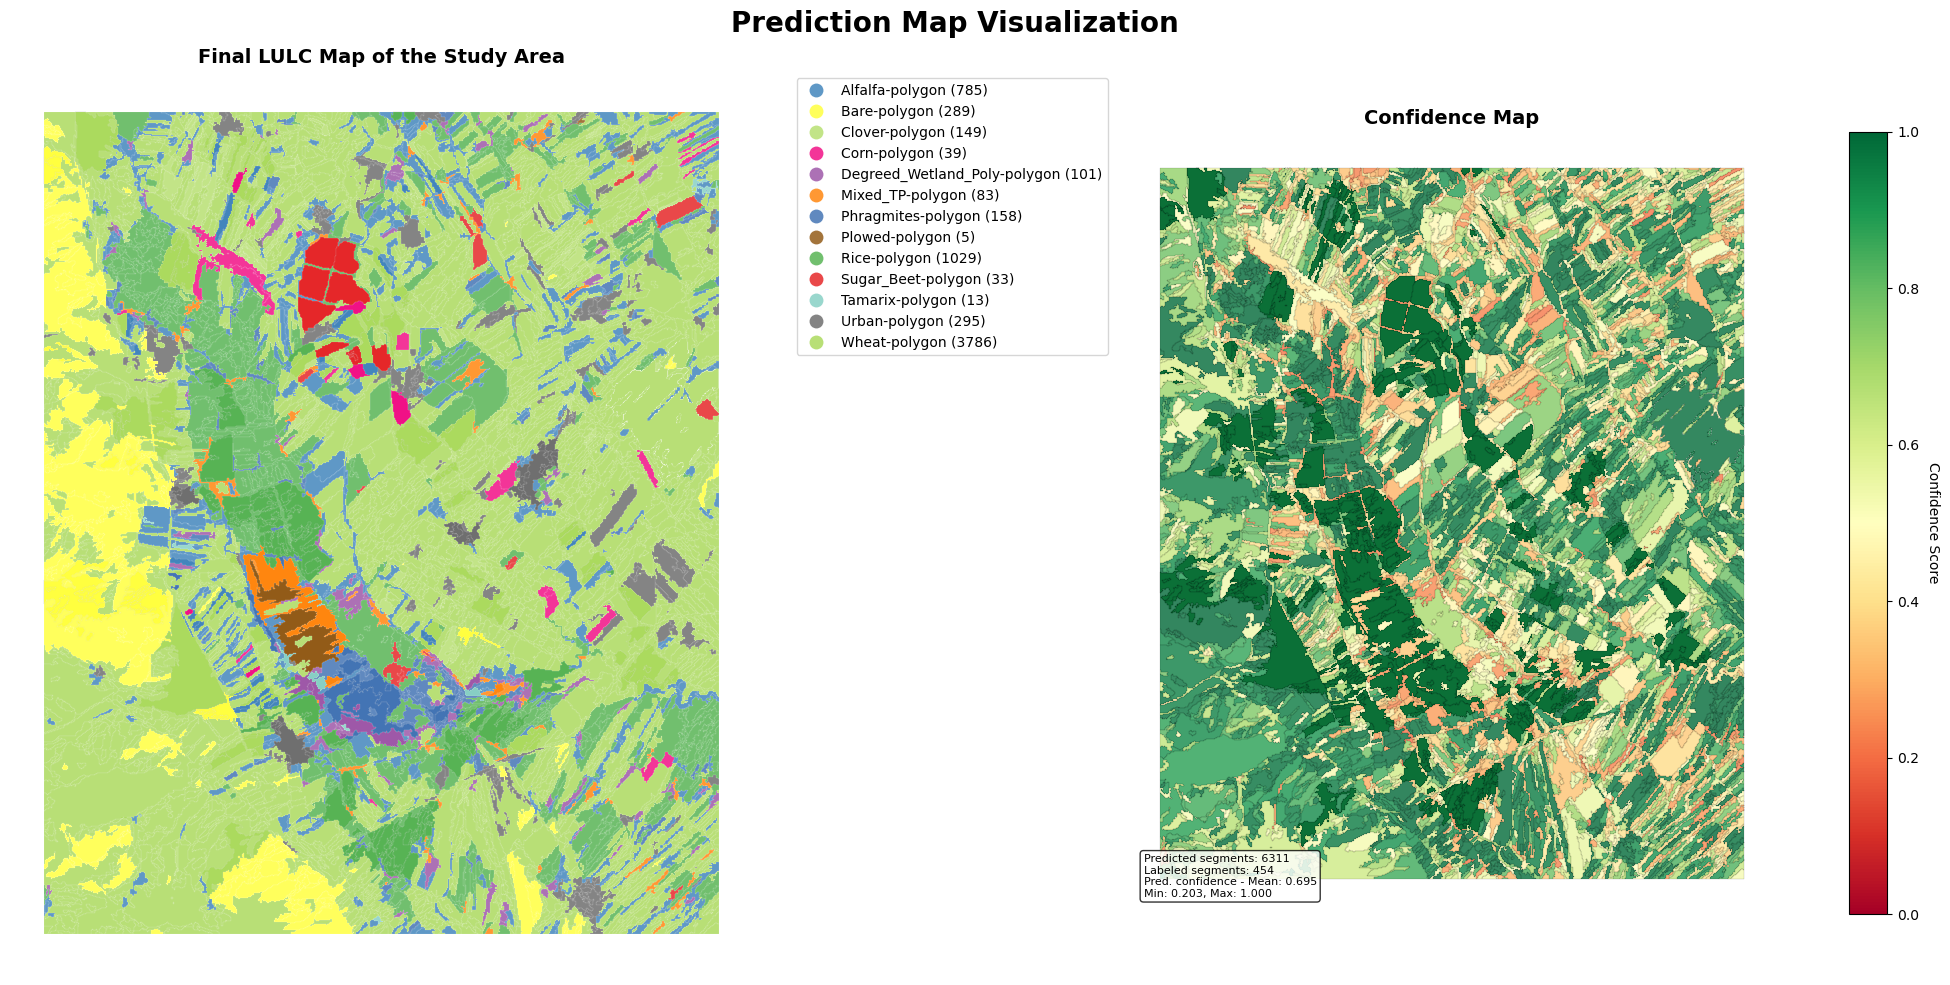

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt
from matplotlib.colors import ListedColormap
import os
import numpy as np

# File paths
input_csv = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\Enhanced_Classification_Results_AllClasses_NOFE_Aug\final_dataset_enhanced_all.csv"
base_csv = r"F:\_____My_Thesies____\_ImpFiles\4. LULC\1.Feature_Engineered\2.RawFeature_AllClass\final_dataset_all.csv"
output_dir = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\4.AugModel_On_No_F-E_Data\Enhanced_Classification_Results_AllClasses_NOFE_Aug\Enhanced_Map"

custom_palette = {
    'Alfalfa-polygon': '#377eb8',
    'Bare-polygon': '#ffff33',
    'Clover-polygon': '#b3de69',
    'Corn-polygon': '#f0027f',
    'Degreed_Wetland_Poly-polygon': '#984ea3',
    'Degreed_Medland_Poly-polygon': '#984ea3',  # Alternative name seen in your image
    'Mixed_TP-polygon': '#ff7f00',
    'Mixed_Ti-Polygon': '#ff7f00',  # Alternative name
    'Phragmites-polygon': '#386cb0',
    'Phragmine-polygon': '#386cb0',  # Alternative name
    'Plowed-polygon': '#8c510a',
    'Rice-polygon': '#4daf4a',
    'Sugar_Beet-polygon': '#e41a1c',
    'Sugar-Bare-polygon': '#e41a1c',  # Alternative name
    'Tamarix-polygon': '#80cdc1',
    'Urban-polygon': '#666666',
    'Wheat-polygon': '#a6d854',
    'Whack-polygon': '#a6d854'  # Assuming this is a typo for Wheat
}

def robust_geometry_parser(geom_string):
    """More robust geometry parsing function"""
    if pd.isna(geom_string) or geom_string == '' or str(geom_string).strip() == '':
        return None
    
    geom_str = str(geom_string).strip()
    
    try:
        if geom_str.upper().startswith(('POLYGON', 'MULTIPOLYGON', 'POINT', 'LINESTRING')):
            geom = wkt.loads(geom_str)
            if geom.is_valid:
                return geom
            else:
                fixed_geom = geom.buffer(0)
                if fixed_geom.is_valid:
                    return fixed_geom
        return None
    except:
        return None

# Load the prediction CSV file
df = pd.read_csv(input_csv)

# Load the base CSV file for labeled segments
base_df = pd.read_csv(base_csv)
labeled_segments = base_df[base_df['layer'].notna()].copy()  # Only segments with labels

if 'geometry' not in df.columns:
    print("⚠️ No geometry column found. Skipping map creation.")
else:
    # Parse geometries for predictions
    df['parsed_geometry'] = df['geometry'].apply(robust_geometry_parser)
    
    # Parse geometries for labeled segments
    labeled_segments['parsed_geometry'] = labeled_segments['geometry'].apply(robust_geometry_parser)
    
    # Count valid geometries
    valid_pred_mask = df['parsed_geometry'].notna()
    valid_labeled_mask = labeled_segments['parsed_geometry'].notna()
    
    # Create GeoDataFrames
    pred_gdf = gpd.GeoDataFrame(df[valid_pred_mask], geometry='parsed_geometry') if valid_pred_mask.sum() > 0 else None
    labeled_gdf = gpd.GeoDataFrame(labeled_segments[valid_labeled_mask], geometry='parsed_geometry') if valid_labeled_mask.sum() > 0 else None
    
    # Set CRS
    for gdf in [pred_gdf, labeled_gdf]:
        if gdf is not None:
            bounds = gdf.bounds
            if (bounds['minx'].min() >= -180 and bounds['maxx'].max() <= 180 and
                bounds['miny'].min() >= -90 and bounds['maxy'].max() <= 90):
                gdf.set_crs('EPSG:4326', inplace=True)
            else:
                gdf.set_crs('EPSG:3857', inplace=True)
    
    # Get unique classes from both
    all_classes = pd.concat([labeled_gdf['layer'] if labeled_gdf is not None else pd.Series(), 
                             pred_gdf['predicted_layer'] if pred_gdf is not None else pd.Series()]).dropna().unique()
    unique_classes = sorted(all_classes)
    
    # Create color list
    colors = [custom_palette.get(cls, '#808080') for cls in unique_classes]  # default gray
    custom_cmap = ListedColormap(colors)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    fig.suptitle('Prediction Map Visualization', fontsize=20, fontweight='bold')
    
    # Map 1: Predicted layers + Labeled segments
    ax1 = axes[0]
    
    # Plot labeled segments first (as background)
    if labeled_gdf is not None:
        labeled_gdf.plot(column='layer', ax=ax1, alpha=0.7, edgecolor='black',
                         linewidth=0.1, cmap=custom_cmap, categorical=True, legend=False)
    
    # Plot predicted segments on top
    if pred_gdf is not None and 'predicted_layer' in pred_gdf.columns:
        pred_gdf.plot(column='predicted_layer', ax=ax1, legend=True,
              alpha=0.8, edgecolor='white', linewidth=0.1, cmap=custom_cmap, categorical=True,
              legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'})

        
        # Add class counts to legend
        legend = ax1.get_legend()
        if legend:
            for text in legend.get_texts():
                class_name = text.get_text()
                pred_count = (pred_gdf['predicted_layer'] == class_name).sum() if 'predicted_layer' in pred_gdf.columns else 0
                labeled_count = (labeled_gdf['layer'] == class_name).sum() if 'layer' in labeled_gdf.columns else 0
                total_count = pred_count + labeled_count
                text.set_text(f"{class_name} ({total_count})")
    
    ax1.set_title('Final LULC Map of the Study Area', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # Map 2: Confidence (predictions=actual confidence, labeled=0.99)
    ax2 = axes[1]
    
    # Plot labeled segments with confidence 0.99
    if labeled_gdf is not None:
        labeled_gdf.plot(ax=ax2, color='darkgreen', alpha=0.8, edgecolor='black',
                         linewidth=0.1, label='Labeled (conf=0.99)')
    
    # Plot predicted segments with their confidence
    if pred_gdf is not None and 'prediction_confidence' in pred_gdf.columns:
        conf_data = pred_gdf[pred_gdf['prediction_confidence'].notna()]
        if len(conf_data) > 0:
            im = conf_data.plot(column='prediction_confidence', ax=ax2, legend=False,
                                cmap='RdYlGn', alpha=0.8, edgecolor='black', linewidth=0.1,
                                vmin=0, vmax=1)
            
            # Add colorbar
            divider = make_axes_locatable(ax2)
            cax = divider.append_axes("right", size="5%", pad=0.1)
            
            sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=0, vmax=1))
            sm.set_array([])
            cbar = plt.colorbar(sm, cax=cax)
            cbar.set_label('Confidence Score', rotation=270, labelpad=15)
            
            # Add confidence statistics
            conf_values = conf_data['prediction_confidence'].values
            total_labeled = len(labeled_gdf) if labeled_gdf is not None else 0
            conf_stats = f"Predicted segments: {len(conf_data)}\nLabeled segments: {total_labeled}\nPred. confidence - Mean: {conf_values.mean():.3f}\nMin: {conf_values.min():.3f}, Max: {conf_values.max():.3f}"
            ax2.text(0.02, 0.02, conf_stats, transform=ax2.transAxes,
                     verticalalignment='bottom', fontsize=8,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax2.set_title('Confidence Map', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    
    # Save the figure
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, 'complete_prediction_map_custom.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✅ Complete prediction map saved to: {output_path}")
    
    plt.show()